In [1]:
import numpy as np
import matplotlib.pyplot as plt
from StrainCalculator import LocalWavevectorMap, get_strain, get_displacement, correct_strain
import Pretreatment
import findiff
plt.rcParams['figure.dpi'] = 120

# Load Generated Data

Please first run the generate_lattice.py script to generate the data. Once this done, the generated data is a npz file containing I0, noise, U_dr_x, U_dr_y, U_ph_x and U_ph_y. U_dr_i and U_ph_i will then be added together to form the total displacement field.

In [2]:
# Load Generated Data
# Please first run the generate_lattice.py script to generate the data
dir_generated_data = './GeneratedData/Generated_Lattice_Data.npz'
dir_data = './Results/'


GeneratedData = np.load(dir_generated_data)

L0 = GeneratedData['L0'] # Size of the image
R1 = GeneratedData['R1'] # Primitive lattice vector 1
R2 = GeneratedData['R2'] # Primitive lattice vector 2

# Calculate reciprocal lattice vectors
v = abs(R1[0] * R2[1] - R1[1] * R2[0])
Q1 = np.array([R2[1], -R2[0]])/v * np.pi * 2
Q2 = np.array([-R1[1], R1[0]])/v * np.pi * 2

I = GeneratedData['I0']  # Image
noise = GeneratedData['noise']  # Data Noise
Ux_dr = GeneratedData['U_dr_x'] # Drifting Displacement field x
Uy_dr = GeneratedData['U_dr_y'] # Drifting Displacement field y
Ux_ph = GeneratedData['U_ph_x'] # Physical Displacement field x
Uy_ph = GeneratedData['U_ph_y'] # Physical Displacement field y

Ux_total = Ux_dr + Ux_ph # Total Displacement field x
Uy_total = Uy_dr + Uy_ph # Total Displacement field y

# Prepare grids and calculate strain

One the data is obtained, the strain will be be calculated directly through the derivative. x/y and kx/ky grids will also be created in this step.

In [3]:
# Compute the strain tensor components
Dx = findiff.FinDiff(1, L0 / (I.shape[1] - 1)) # Differentiation operator in x-direction
Dy = findiff.FinDiff(0, L0 / (I.shape[0] - 1)) # Differentiation operator in y-direction

Exx = Dx(Ux_total) # Total strain xx
Exy = Dy(Ux_total) # Total strain xy
Eyx = Dx(Uy_total) # Total strain yx
Eyy = Dy(Uy_total) # Total strain yy
Exx_ph = Dx(Ux_ph) # Physical strain xx
Exy_ph = Dy(Ux_ph) # Physical strain xy
Eyx_ph = Dx(Uy_ph) # Physical strain yx
Eyy_ph = Dy(Uy_ph) # Physical strain yy

# x, y grids for plotting
x = np.linspace(0, L0, I.shape[1])
y = np.linspace(0, L0, I.shape[0])
kx = np.linspace(-np.pi / (L0 / I.shape[1]), np.pi / (L0 / I.shape[1]), I.shape[1])
ky = np.linspace(-np.pi / (L0 / I.shape[0]), np.pi / (L0 / I.shape[0]), I.shape[0])

# Compute the fft of the image
I_fft = np.fft.fftshift(np.fft.fft2(I))

# Show displacement and strain fields

Text(0, 0.5, 'y')

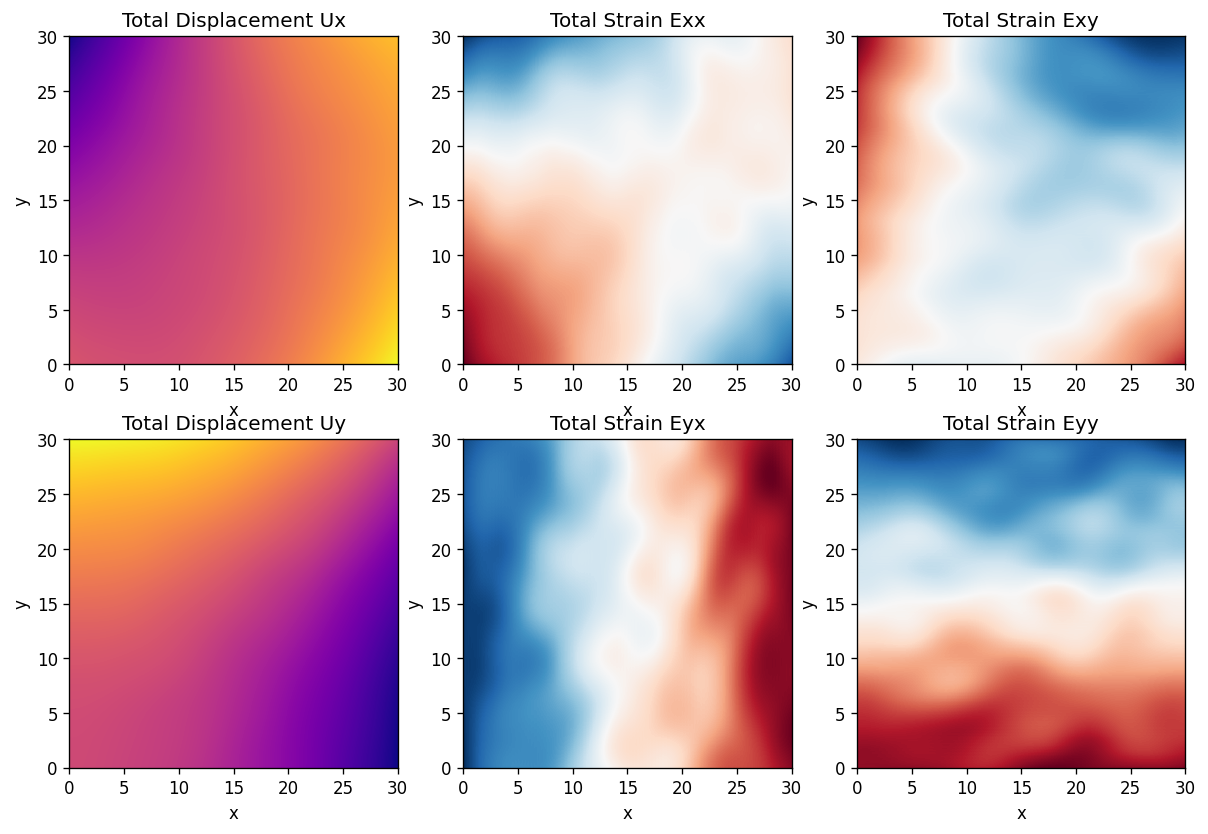

In [4]:
# Show displacement and strain fields
fig = plt.figure(figsize=(12, 8))
ax_Ux = fig.add_subplot(231)
ax_Uy = fig.add_subplot(234)
ax_Exx = fig.add_subplot(232)
ax_Exy = fig.add_subplot(233)
ax_Eyx = fig.add_subplot(235)
ax_Eyy = fig.add_subplot(236)

color_map_U = 'plasma'
color_map_E = 'RdBu'

ax_Ux.pcolorfast(x, y, Ux_total, cmap=color_map_U)
ax_Ux.set_title('Total Displacement Ux')
ax_Ux.set_aspect('equal')
ax_Ux.set_xlabel('x')
ax_Ux.set_ylabel('y')

ax_Uy.pcolorfast(x, y, Uy_total, cmap=color_map_U)
ax_Uy.set_title('Total Displacement Uy')
ax_Uy.set_aspect('equal')
ax_Uy.set_xlabel('x')
ax_Uy.set_ylabel('y')

ax_Exx.pcolorfast(x, y, Exx, cmap=color_map_E)
ax_Exx.set_title('Total Strain Exx')
ax_Exx.set_aspect('equal')
ax_Exx.set_xlabel('x')
ax_Exx.set_ylabel('y')

ax_Exy.pcolorfast(x, y, Exy, cmap=color_map_E)
ax_Exy.set_aspect('equal')
ax_Exy.set_xlabel('x')
ax_Exy.set_ylabel('y')
ax_Exy.set_title('Total Strain Exy')

ax_Eyx.pcolorfast(x, y, Eyx, cmap=color_map_E)
ax_Eyx.set_aspect('equal')
ax_Eyx.set_xlabel('x')
ax_Eyx.set_ylabel('y')
ax_Eyx.set_title('Total Strain Eyx')

ax_Eyy.pcolorfast(x, y, Eyy, cmap=color_map_E)
ax_Eyy.set_title('Total Strain Eyy')
ax_Eyy.set_aspect('equal')
ax_Eyy.set_xlabel('x')
ax_Eyy.set_ylabel('y')


# Show the image with strain and its fft

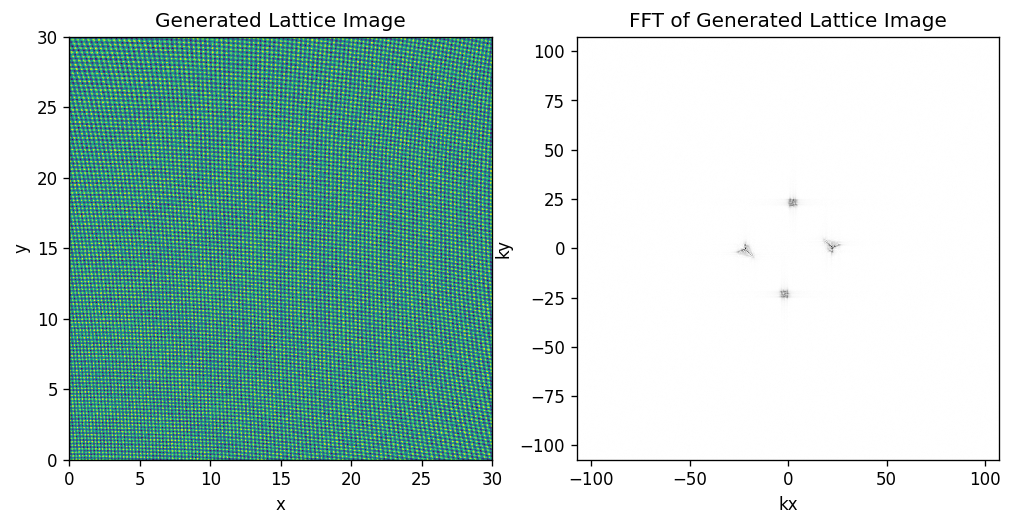

In [5]:
fig = plt.figure(figsize=(10, 5))
ax_I = fig.add_subplot(121)
ax_I_fft = fig.add_subplot(122)

ax_I.pcolorfast(x, y, I)
ax_I.set_xlabel('x')
ax_I.set_ylabel('y')
ax_I.set_title('Generated Lattice Image')
ax_I.set_aspect('equal')

ax_I_fft.pcolorfast(kx, ky, np.abs(I_fft), cmap='gray_r')
ax_I_fft.set_xlabel('kx')
ax_I_fft.set_ylabel('ky')
ax_I_fft.set_title('FFT of Generated Lattice Image')
ax_I_fft.set_aspect('equal')

# Define modulate vectors

Now the data is ready, we will use the LWM algorithm to extract strain from the image. 

The first step is to define the modulated vectors. For each Bragg vector Q, two modulate q vecotrs are needed at least. In this tutorial these are Q1_calc and Q2_calc. These two variables need to be N x 2 size variables and each row corresponds to a modulate vector. It is worth noting that these Q vectors are vectors after the modulation rather than the vecotr to be modulated to the Bragg vectors.

The LWM is designed that can take more than two modulate vectors for each Bragg vector. If you input more than two modulate vecotrs for a single Bragg vector, it will use least square method to average over.

When chossing the modulate vector, 0 and 90 degree direction should be avoided since this may induce aliasing in the later gradient map and hough transform. Similarly, 45 degree should also be avoided. The bast option, based on my experience is some value close, but not equal to 45 degree.

In [6]:
# Modulate vectors. 
# Q1_calc and Q2_calc are the reciprocal lattice vectors after the modulation.
th = np.array([41, -43]) * np.pi / 180 # Angles, 0, 90 and 45 should be avoided because of aliasing.
Q1_calc = np.zeros((th.shape[0], 2))
Q2_calc = np.zeros((th.shape[0], 2))
rQ1 = np.sqrt(Q1[0]**2 + Q1[1]**2)
rQ2 = np.sqrt(Q2[0]**2 + Q2[1]**2)

for i in range(0, th.shape[0]):
    Q1_calc[i] = np.array([np.cos(th[i]), np.sin(th[i])]) * rQ1 * 3**0.5
    Q2_calc[i] = np.array([np.cos(th[i]), np.sin(th[i])]) * rQ2 * 3**0.5

# Define the LWM calculator
Currently the image and region conducting LWM measurements can only be a square.

In [7]:
'''
x x x x x x x x x x IMAGE x x x x x x x x x x
x                                           x
x     ..............REGION.............     x
x     .                               .     x
x     .   o Mask  o                   .     x
x     .   o       o                   .     x
x     .   o       o ------------>     .     x
x     .   o o o o o                   .     x
x     .       l                       .     x
x     .       l                       .     x
x     .       l                       .     x
x     .       l                       .     x
x     .       l                       .     x
x     .       V                       .     x
x     .................................     x
x                                           x
x<---------------- L_image ---------------->x
x x x x x x x x x x x x x x x x x x x x x x x
'''

# Define the LWM calculator
L_image = L0
L_region = L0 - 2.1
L_mask = 2.0
N_region = 200

calc = LocalWavevectorMap(I,                 # Image
                          L_image,           # Width of the image, must be a number and the image must be square
                          L_region=L_region, # Width of the region for local wavevector calculation
                          N_region=N_region, # Number of points in the region for local wavevector calculation
                          L_mask=L_mask,     # Width of the mask for local wavevector calculation
                          )

# Calculate Q vecotrs

In [8]:
Q1_x, Q1_y, Q2_x, Q2_y = calc.calc_local_wavevector(
                        Q1, Q2,       # Original reciprocal lattice vectors                           
                        Q_width=10.0, # Width of Q Mask
                        alpha=10.0,   # Sharpness of the FD filter for the Q mask, if None, use Gaussian filter
                        Q1_calc=Q1_calc, Q2_calc=Q2_calc, 
                        N_interp=2,          # Interpolation factor
                        show_process=False,  # If true, plot each step.
                        canny_low_threshold=-1e-4, # Canny edge detection low threshold
                        canny_high_threshold=1e-4, # Canny edge detection high threshold
                        canny_sigma=5.0,           # Canny edge detection Gaussian filter sigma, control the edge smoothness
                        th1_calc=th, th2_calc=th,  # Initial angle
                        )

# Calculate strain and displacement

In [9]:
# Strain
exx, exy, eyx, eyy = get_strain(Q1_x, Q1_y, Q2_x, Q2_y, 
                                Q1i=Q1, Q2i=Q2, 
                                subtract_linear=False)

# Displacement
ux, uy = get_displacement(exx, exy, eyx, eyy, Lx=calc.L_region[1], Ly=calc.L_region[0])

# Correct the displacement
I_corrected = correct_strain(I=calc.I_valid, Lx=calc.L_region[0], Ly=calc.L_region[1], ux=ux, uy=uy)

# Transfer the strain from the regular frame (eij) to the image frame (eij_r)

In [10]:
# Transfer the strain from the regular frame (eij) to the image frame (eij_r)

F = np.zeros((N_region, N_region, 2, 2), dtype=float)
H = np.zeros((N_region, N_region, 2, 2), dtype=float)

F[:, :, 0, 0] = 1 + exx
F[:, :, 0, 1] = exy
F[:, :, 1, 0] = eyx
F[:, :, 1, 1] = 1 + eyy

H[:, :, 0, 0] = exx
H[:, :, 0, 1] = exy
H[:, :, 1, 0] = eyx
H[:, :, 1, 1] = eyy
H_corrected = np.linalg.inv(F) @ H

exx_r = H_corrected[:, :, 0 ,0]
exy_r = H_corrected[:, :, 0 ,1]
eyx_r = H_corrected[:, :, 1 ,0]
eyy_r = H_corrected[:, :, 1 ,1]

In [11]:
# Save the result for further use
strain_result = {
        'exx_r': exx_r,
        'exy_r': exy_r,
        'eyx_r': eyx_r,
        'eyy_r': eyy_r,
        'exx': exx,
        'exy': exy,
        'eyx': eyx,
        'eyy': eyy,
        'Ux': ux,
        'Uy': uy,
        'I_corrected': I_corrected,
        'L_region': calc.L_region,
        'N_region': calc.N_region,
    }
np.savez('./Strain_Data.tests.npz', **strain_result)

# Show results

In [12]:
# Displacement correction results

# Small Region FFT: The corrected image usually have some white edge that may affect the FFT, 
# so we need to crop the image to a smaller region for FFT calculation. The image with strain
# will also be cropped to the same size for comparison. 
# The size of the cropped region is defined by L_ftt.
L_ftt = 21
N_mid_I0 = int((I.shape[0] - 1) / 2)
N_mid_Ic = int((I_corrected.shape[0] - 1) / 2)

N_width_I0 = int(L_ftt / L0 * I.shape[0] / 2)
N_width_Ic = int(L_ftt / L_region * I_corrected.shape[0] / 2) + 1

# Cropped Original Image with Strain
I0_pure = I[N_mid_I0 - N_width_I0:N_mid_I0 + N_width_I0, N_mid_I0 - N_width_I0:N_mid_I0 + N_width_I0]
# Cropped Image with Strain Corrected
Ic_pure = I_corrected[N_mid_Ic - N_width_Ic:N_mid_Ic + N_width_Ic, N_mid_Ic - N_width_Ic:N_mid_Ic + N_width_Ic]

# FFT
I0_fft = np.fft.fftshift(np.fft.fft2(I0_pure))
Ic_fft = np.fft.fftshift(np.fft.fft2(Ic_pure))

# Define the kx and ky for the FFT images for cropped images.
kx_c = np.linspace(-np.pi / L_ftt * I0_fft.shape[1], np.pi / L_ftt * I0_fft.shape[1], I0_fft.shape[1])
ky_c = np.linspace(-np.pi / L_ftt * I0_fft.shape[0], np.pi / L_ftt * I0_fft.shape[0], I0_fft.shape[0])

r0 = np.sqrt((R1[0])**2 + (R1[1])**2)
k0 = 2 * np.pi / r0

In [13]:
# Quadratic Fitting to separate the physical strain from the total strain. 
# The physical strain is the strain after subtracting the quadratic background.
# The quadratic background is the drifting of the sample during the measurement.

from numpy.linalg import lstsq
from scipy.interpolate import RegularGridInterpolator
# Subtract Quadratic Background of e:
def subtract_quadratic(matrix):
    # Get the dimensions of the input matrix
    rows, cols = matrix.shape

    # Create coordinate matrices for X and Y
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))

    # Prepare the design matrix for least squares fitting
    # This corresponds to a quadratic polynomial with terms up to X^2 and Y^2
    A = np.column_stack([np.ones(X.size),            # A0
                        X.ravel(),                 # A1 * X
                        Y.ravel(),                 # A2 * Y
                        X.ravel()**2,              # B1 * X^2
                        Y.ravel()**2,              # B2 * Y^2
                        X.ravel() * Y.ravel()      # B3 * XY
                        ])

    # Vectorize the matrix for fitting
    Z = matrix.ravel()

    # Solve for the coefficients using least squares
    coeffs, _, _, _ = lstsq(A, Z, rcond=None)

    # Reconstruct the fitted quadratic polynomial
    Z_fit = (coeffs[0] + coeffs[1] * X + coeffs[2] * Y +
            coeffs[3] * X**2 + coeffs[4] * Y**2 + coeffs[5] * X * Y
            )

    # Subtract the fitted polynomial from the original matrix
    result = matrix - Z_fit

    return result, coeffs  # Return the result and the coefficients



exx_ph, coeffs_exx_calc = subtract_quadratic(exx_r)
exy_ph, coeffs_exy_calc = subtract_quadratic(exy_r)
eyx_ph, coeffs_eyx_calc = subtract_quadratic(eyx_r)
eyy_ph, coeffs_eyy_calc = subtract_quadratic(eyy_r)

In [14]:
# Interpolate Exx_ph to match the size of exx_ph
X_region, Y_region = np.meshgrid(calc.x_region, calc.y_region)
interp_func = RegularGridInterpolator((x, y), Exx_ph.T)
Exx_ph_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Exy_ph.T)
Exy_ph_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Eyx_ph.T)
Eyx_ph_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Eyy_ph.T)
Eyy_ph_interp = interp_func((X_region, Y_region))

interp_func = RegularGridInterpolator((x, y), Exx.T)
Exx_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Exy.T)
Exy_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Eyx.T)
Eyx_interp = interp_func((X_region, Y_region))
interp_func = RegularGridInterpolator((x, y), Eyy.T)
Eyy_interp = interp_func((X_region, Y_region))

error_xx_ph = np.sqrt(np.mean((Exx_ph_interp - exx_ph)**2))
error_xy_ph = np.sqrt(np.mean((Exy_ph_interp - exy_ph)**2))
error_yx_ph = np.sqrt(np.mean((Eyx_ph_interp - eyx_ph)**2))
error_yy_ph = np.sqrt(np.mean((Eyy_ph_interp - eyy_ph)**2))

error_xx = np.sqrt(np.mean((Exx_interp - exx_r)**2))
error_xy = np.sqrt(np.mean((Exy_interp - exy_r)**2))
error_yx = np.sqrt(np.mean((Eyx_interp - eyx_r)**2))
error_yy = np.sqrt(np.mean((Eyy_interp - eyy_r)**2))

print('Error, Total Strain')
print('Exx: %.5f' % error_xx)
print('Exy: %.5f' % error_xy)
print('Eyx: %.5f' % error_yx)
print('Eyy: %.5f' % error_yy)
print('Error, Physical Strain')
print('Exx: %.5f' % error_xx_ph)
print('Exy: %.5f' % error_xy_ph)
print('Eyx: %.5f' % error_yx_ph)
print('Eyy: %.5f' % error_yy_ph)

Error, Total Strain
Exx: 0.00099
Exy: 0.00101
Eyx: 0.00088
Eyy: 0.00071
Error, Physical Strain
Exx: 0.00161
Exy: 0.00240
Eyx: 0.00186
Eyy: 0.00148


170
152


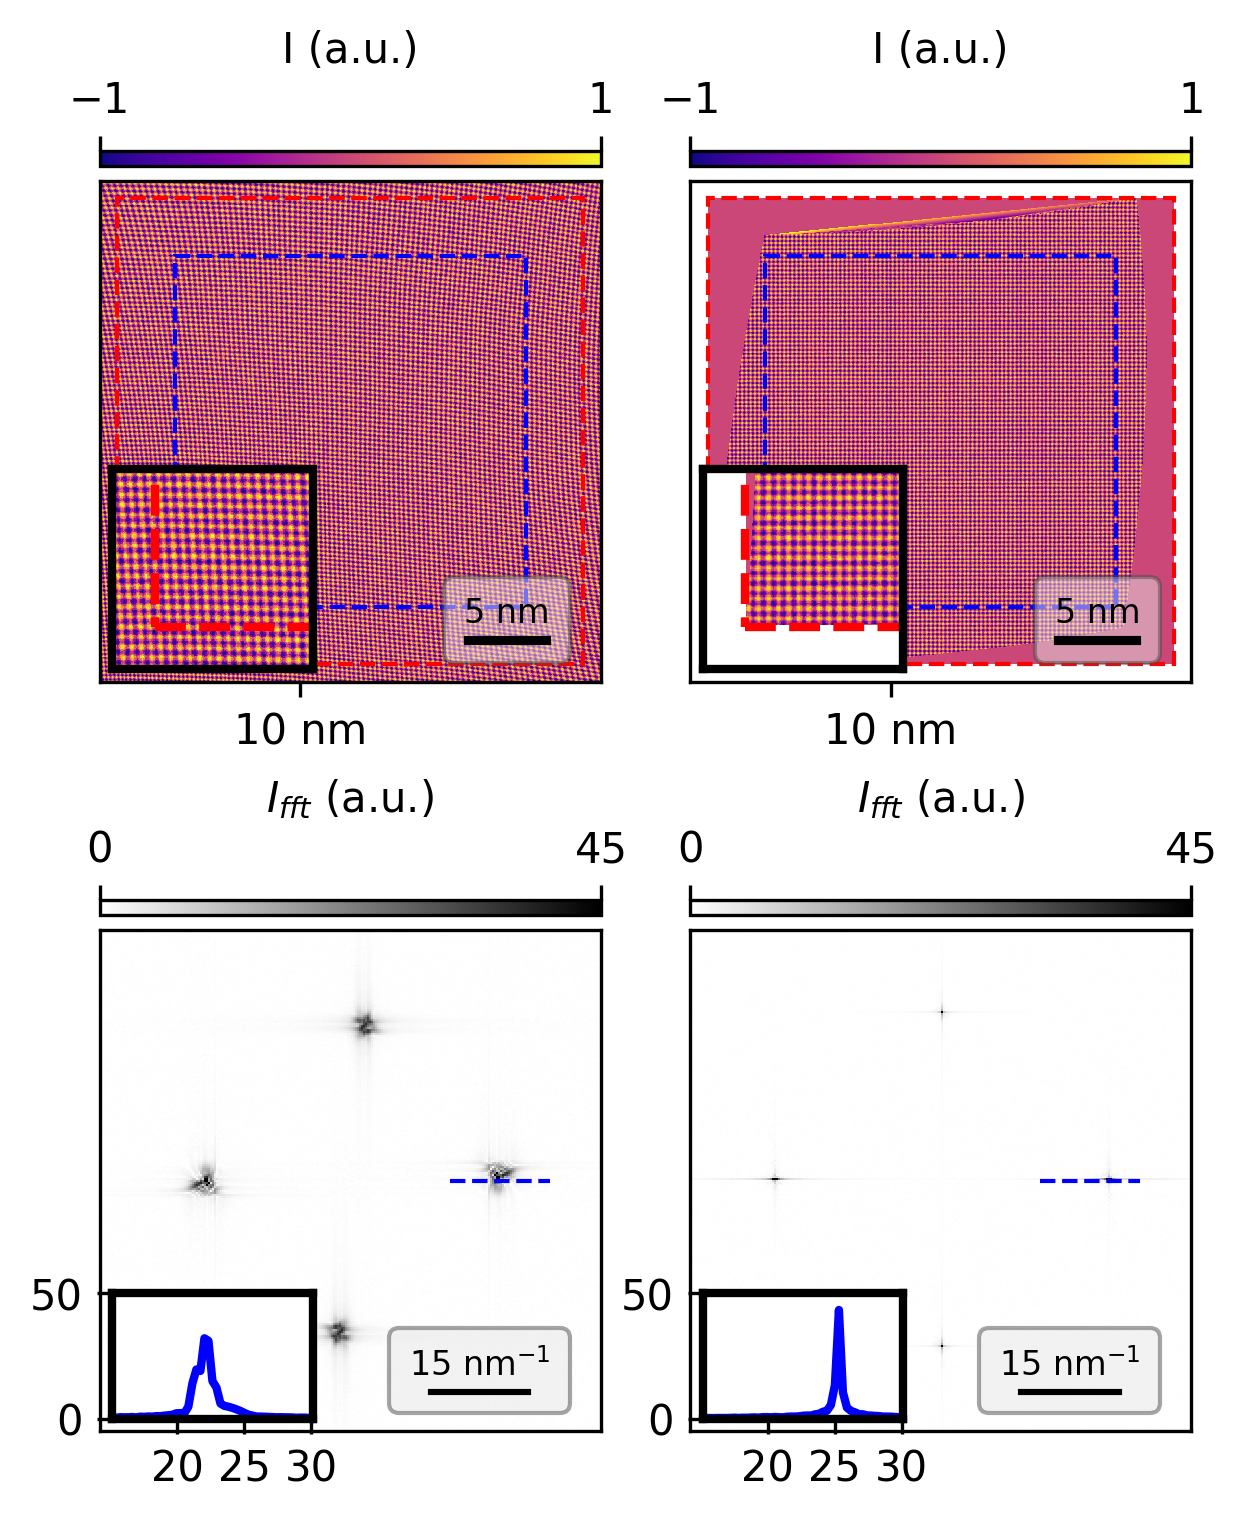

In [15]:
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 150
fig_correction = plt.figure(figsize=(4.13, 5.0))
ax_I0 = fig_correction.add_subplot(2, 2, 1)
ax_Ic = fig_correction.add_subplot(2, 2, 2)

ax_I0_fft = fig_correction.add_subplot(2, 2, 3)
ax_Ic_fft = fig_correction.add_subplot(2, 2, 4)


p = ax_I0.pcolorfast(x, y, I, cmap='plasma', vmin=-1.0, vmax=1.0, rasterized=True)
ax_I0.set_xlim(0, L0)
ax_I0.set_ylim(0, L0)
ax_I0.set_xticks([0.4 * 30])
ax_I0.set_xticklabels(['10 nm'])
ax_I0.set_yticks([])
BOUNDARY = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), L_region, L_region, linewidth=1, edgecolor='r', linestyle='--', facecolor='none')
FFT_REGION = mpatches.Rectangle(((L0 - L_ftt) / 2, (L0 - L_ftt) / 2), L_ftt, L_ftt, linewidth=1, edgecolor='b', linestyle='--', facecolor='none')
scale_bar_E = AnchoredSizeBar(ax_I0.transData,  5, '5 nm', 
                                'lower right', pad=0.3, label_top=True,
                                color='black', frameon=True, size_vertical=0.3,
                                fontproperties={'size': 8},
                                bbox_to_anchor=(0.925, 0.05),     # shift from edges
                                bbox_transform=ax_I0.transAxes,)
scale_bar_E.patch.set_facecolor('0.9')   # light gray
scale_bar_E.patch.set_edgecolor('0.3')
scale_bar_E.patch.set_alpha(0.5)
scale_bar_E.patch.set_boxstyle("round")
ax_I0.add_artist(scale_bar_E)
ax_I0.add_patch(BOUNDARY)
ax_I0.add_patch(FFT_REGION)
ax_I0.set_aspect('equal')

divider = make_axes_locatable(ax_I0)
ax_I0_cbar = divider.append_axes('top', 0.05, pad=0.05)
fig_correction.colorbar(p, cax=ax_I0_cbar, orientation='horizontal', pad=0.05)
ax_I0_cbar.set_xticks([-1.0, 1.0])
ax_I0_cbar.set_xlabel('I (a.u.)')
ax_I0_cbar.xaxis.set_ticks_position('top')
ax_I0_cbar.xaxis.set_label_position('top')
# fig_correction.colorbar(map_e, cax=ax, orientation='horizontal', pad=0.1)





p = ax_Ic.pcolorfast(calc.x_valid, calc.y_valid, I_corrected, cmap='plasma', vmin=-1.0, vmax=1.0, rasterized=True)
ax_Ic.set_xlim(0, L0)
ax_Ic.set_ylim(0, L0)
ax_Ic.set_xticks([0.4 * 30])
ax_Ic.set_xticklabels(['10 nm'])
ax_Ic.set_yticks([])
BOUNDARY = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), L_region, L_region, linewidth=1, edgecolor='r', linestyle='--', facecolor='none')
FFT_REGION = mpatches.Rectangle(((L0 - L_ftt) / 2, (L0 - L_ftt) / 2), L_ftt, L_ftt, linewidth=1, edgecolor='b', linestyle='--', facecolor='none')
scale_bar_E = AnchoredSizeBar(ax_Ic.transData,  5, '5 nm', 
                                'lower right', pad=0.3, label_top=True,
                                color='black', frameon=True, size_vertical=0.3,
                                fontproperties={'size': 8},
                                bbox_to_anchor=(0.925, 0.05),     # shift from edges
                                bbox_transform=ax_Ic.transAxes,)
scale_bar_E.patch.set_facecolor('0.9')   # light gray
scale_bar_E.patch.set_edgecolor('0.3')
scale_bar_E.patch.set_alpha(0.5)
scale_bar_E.patch.set_boxstyle("round")

ax_Ic.add_artist(scale_bar_E)
ax_Ic.add_patch(BOUNDARY)
ax_Ic.add_patch(FFT_REGION)
ax_Ic.set_aspect('equal')

divider = make_axes_locatable(ax_Ic)
ax_Ic_cbar = divider.append_axes('top', 0.05, pad=0.05)
fig_correction.colorbar(p, cax=ax_Ic_cbar, orientation='horizontal', pad=0.1)
ax_Ic_cbar.set_xticks([-1.0, 1.0])
ax_Ic_cbar.set_xlabel('I (a.u.)')
ax_Ic_cbar.xaxis.set_ticks_position('top')
ax_Ic_cbar.xaxis.set_label_position('top')



# p = ax_I0_fft.pcolorfast(kx, ky, abs(I0_fft), cmap='gray_r', vmin=0, vmax=int((0.2 * np.max(abs(I0_fft)) / 500)) * 500, rasterized=True)
p = ax_I0_fft.pcolorfast(kx_c, ky_c, abs(I0_fft), cmap='gray_r', vmin=0, vmax=45 * 500, rasterized=True)
ax_I0_fft.set_aspect('equal')
ax_I0_fft.set_xticks([])
ax_I0_fft.set_yticks([])
scale_bar_E = AnchoredSizeBar(ax_I0_fft.transData,  15, '15 nm$^{-1}$', 
                                'lower right', pad=0.3, label_top=True,
                                color='black', frameon=True, size_vertical=0.3,
                                fontproperties={'size': 8},
                                bbox_to_anchor=(0.925, 0.05),     # shift from edges
                                bbox_transform=ax_I0_fft.transAxes,)
scale_bar_E.patch.set_facecolor('0.9')   # light gray
scale_bar_E.patch.set_edgecolor('0.3')
scale_bar_E.patch.set_alpha(0.5)
scale_bar_E.patch.set_boxstyle("round")
ax_I0_fft.add_artist(scale_bar_E)

divider = make_axes_locatable(ax_I0_fft)
ax_I0fft_cbar = divider.append_axes('top', 0.05, pad=0.05)
fig_correction.colorbar(p, cax=ax_I0fft_cbar, orientation='horizontal', pad=0.1)
ax_I0fft_cbar.set_xticks([0, 45 * 500])
ax_I0fft_cbar.set_xticklabels([0, 45])
ax_I0fft_cbar.set_xlabel('$I_{fft}$ (a.u.)')
ax_I0fft_cbar.xaxis.set_ticks_position('top')
ax_I0fft_cbar.xaxis.set_label_position('top')



# p = ax_Ic_fft.pcolorfast(kx, ky, abs(Ic_fft), cmap='gray_r', vmin=0, vmax=int((0.2 * np.max(abs(Ic_fft)) / 500)) * 500, rasterized=True)
p = ax_Ic_fft.pcolorfast(kx_c, ky_c, abs(Ic_fft), cmap='gray_r', vmin=0, vmax=45 * 500, rasterized=True)
ax_Ic_fft.set_aspect('equal')
ax_Ic_fft.set_xticks([])
ax_Ic_fft.set_yticks([])
scale_bar_E = AnchoredSizeBar(ax_Ic_fft.transData,  15, '15 nm$^{-1}$', 
                            'lower right', pad=0.3, label_top=True,
                            color='black', frameon=True, size_vertical=0.3,
                            fontproperties={'size': 8},
                            bbox_to_anchor=(0.925, 0.05),     # shift from edges
                            bbox_transform=ax_Ic_fft.transAxes,)
scale_bar_E.patch.set_facecolor('0.9')   # light gray
scale_bar_E.patch.set_edgecolor('0.3')
scale_bar_E.patch.set_alpha(0.5)
scale_bar_E.patch.set_boxstyle("round")
ax_Ic_fft.add_artist(scale_bar_E)

divider = make_axes_locatable(ax_Ic_fft)
ax_Icfft_cbar = divider.append_axes('top', 0.05, pad=0.05)
fig_correction.colorbar(p, cax=ax_Icfft_cbar, orientation='horizontal', pad=0.1)
ax_Icfft_cbar.set_xticks([0, 45 * 500])
ax_Icfft_cbar.set_xticklabels([0, 45])
ax_Icfft_cbar.set_xlabel('$I_{fft}$ (a.u.)')
ax_Icfft_cbar.xaxis.set_ticks_position('top')
ax_Icfft_cbar.xaxis.set_label_position('top')



ax_I0_fft.set_xlim(-1.5 * k0, 1.5 * k0)
ax_I0_fft.set_ylim(-1.5 * k0, 1.5 * k0)
ax_Ic_fft.set_xlim(-1.5 * k0, 1.5 * k0)
ax_Ic_fft.set_ylim(-1.5 * k0, 1.5 * k0)
fig_correction.tight_layout()


# Zomm in Tops
width_top = 10.0
index_width_top = int(width_top / (x[1] - x[0]) / 2)
print(index_width_top)
N_top = x.shape[0]
I0_zoom = I[0:index_width_top, 0:index_width_top]
x_zoom = x[0:index_width_top]
y_zoom = y[0:index_width_top]

width_topc = width_top - (L0 - L_region) / 2
index_width_topc = int(width_topc / (calc.x_valid[1] - calc.x_valid[0]) / 2)
print(index_width_topc)
N_topc = calc.x_valid.shape[0]
Ic_zoom = I_corrected[0:index_width_topc, 0:index_width_topc]
x_zoomc = calc.x_valid[0:index_width_topc]
y_zoomc = calc.y_valid[0:index_width_topc]

ax_I0_inset = inset_axes(ax_I0, width="40%", height="40%", loc='lower left', borderpad=0.3)
ax_I0_inset.pcolorfast(x_zoom, y_zoom, I0_zoom, cmap='plasma', vmin=-1.0, vmax=1.0, rasterized=True)
BOUNDARY = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), L_region, L_region, linewidth=2, edgecolor='r', linestyle='--', facecolor='none')
ax_I0_inset.add_patch(BOUNDARY)
ax_I0_inset.set_xticks([])
ax_I0_inset.set_yticks([])
ax_I0_inset.set_xlim(x_zoom[0], x_zoom[-1])
ax_I0_inset.set_ylim(y_zoom[0], y_zoom[-1])
for spine in ax_I0_inset.spines.values():
    spine.set_color('black')
    spine.set_linestyle('-')
    spine.set_linewidth(2.0)


ax_Ic_inset = inset_axes(ax_Ic, width="40%", height="40%", loc='lower left', borderpad=0.3)
ax_Ic_inset.pcolorfast(x_zoomc, y_zoomc, Ic_zoom, cmap='plasma', vmin=-1.0, vmax=1.0, rasterized=True)
BOUNDARY = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), L_region, L_region, linewidth=2, edgecolor='r', linestyle='--', facecolor='none')
ax_Ic_inset.add_patch(BOUNDARY)
ax_Ic_inset.set_xticks([])
ax_Ic_inset.set_yticks([])
ax_Ic_inset.set_xlim(x_zoom[0], x_zoom[-1])
ax_Ic_inset.set_ylim(y_zoom[0], y_zoom[-1])
for spine in ax_Ic_inset.spines.values():
    spine.set_color('black')
    spine.set_linestyle('-')
    spine.set_linewidth(2.0)
    
    
# Line Cut FFT
kx_0 = 15.0
kx_1 = 30.0
ky_0 = 0.0
ky_1 = 0.0
dk = 1

index_kx0 = np.argmin(np.abs(kx_c - kx_0))
index_kx1 = np.argmin(np.abs(kx_c - kx_1))
index_ky0 = np.argmin(np.abs(ky_c - ky_0))
index_ky1 = np.argmin(np.abs(ky_c - ky_1))
n_dk = int(dk / (kx_c[1] - kx_c[0]))

LineCut_I0 = I0_fft[index_ky0 - n_dk:index_ky0 + n_dk, index_kx0:index_kx1]
LineCut_Ic = Ic_fft[index_ky0 - n_dk:index_ky0 + n_dk, index_kx0:index_kx1]

LineCut_I0_mean = np.mean(abs(LineCut_I0), axis=0)
LineCut_Ic_mean = np.mean(abs(LineCut_Ic), axis=0)

ax_I0_fft.plot([kx_0, kx_1], [ky_0, ky_1], color='blue', linewidth=1, linestyle='--')
ax_Ic_fft.plot([kx_0, kx_1], [ky_0, ky_1], color='blue', linewidth=1, linestyle='--')

ax_I0_fft_inset = inset_axes(ax_I0_fft, width="40%", height="25%", loc='lower left', borderpad=0.3)
ax_I0_fft_inset.plot(kx_c[index_kx0:index_kx1], LineCut_I0_mean, color='blue', linewidth=2)
ax_I0_fft_inset.set_xticks([15, 20, 25, 30])
ax_I0_fft_inset.set_yticks([0, 50 * 500])
ax_I0_fft_inset.set_yticklabels([0, 50])
ax_I0_fft_inset.set_xlim(kx_c[index_kx0], kx_c[index_kx1])
ax_I0_fft_inset.set_ylim(0, 50 * 500)
for spine in ax_I0_fft_inset.spines.values():
    spine.set_color('black')
    spine.set_linestyle('-')
    spine.set_linewidth(2.0)
    
ax_Ic_fft_inset = inset_axes(ax_Ic_fft, width="40%", height="25%", loc='lower left', borderpad=0.3)
ax_Ic_fft_inset.plot(kx_c[index_kx0:index_kx1], LineCut_Ic_mean, color='blue', linewidth=2)
ax_Ic_fft_inset.set_xticks([15, 20, 25, 30])
ax_Ic_fft_inset.set_yticks([0, 50 * 500])
ax_Ic_fft_inset.set_yticklabels([0, 50])
ax_Ic_fft_inset.set_xlim(kx_c[index_kx0], kx_c[index_kx1])
ax_Ic_fft_inset.set_ylim(0, 50 * 500)
for spine in ax_Ic_fft_inset.spines.values():
    spine.set_color('black')
    spine.set_linestyle('-')
    spine.set_linewidth(2.0)
    
plt.show()

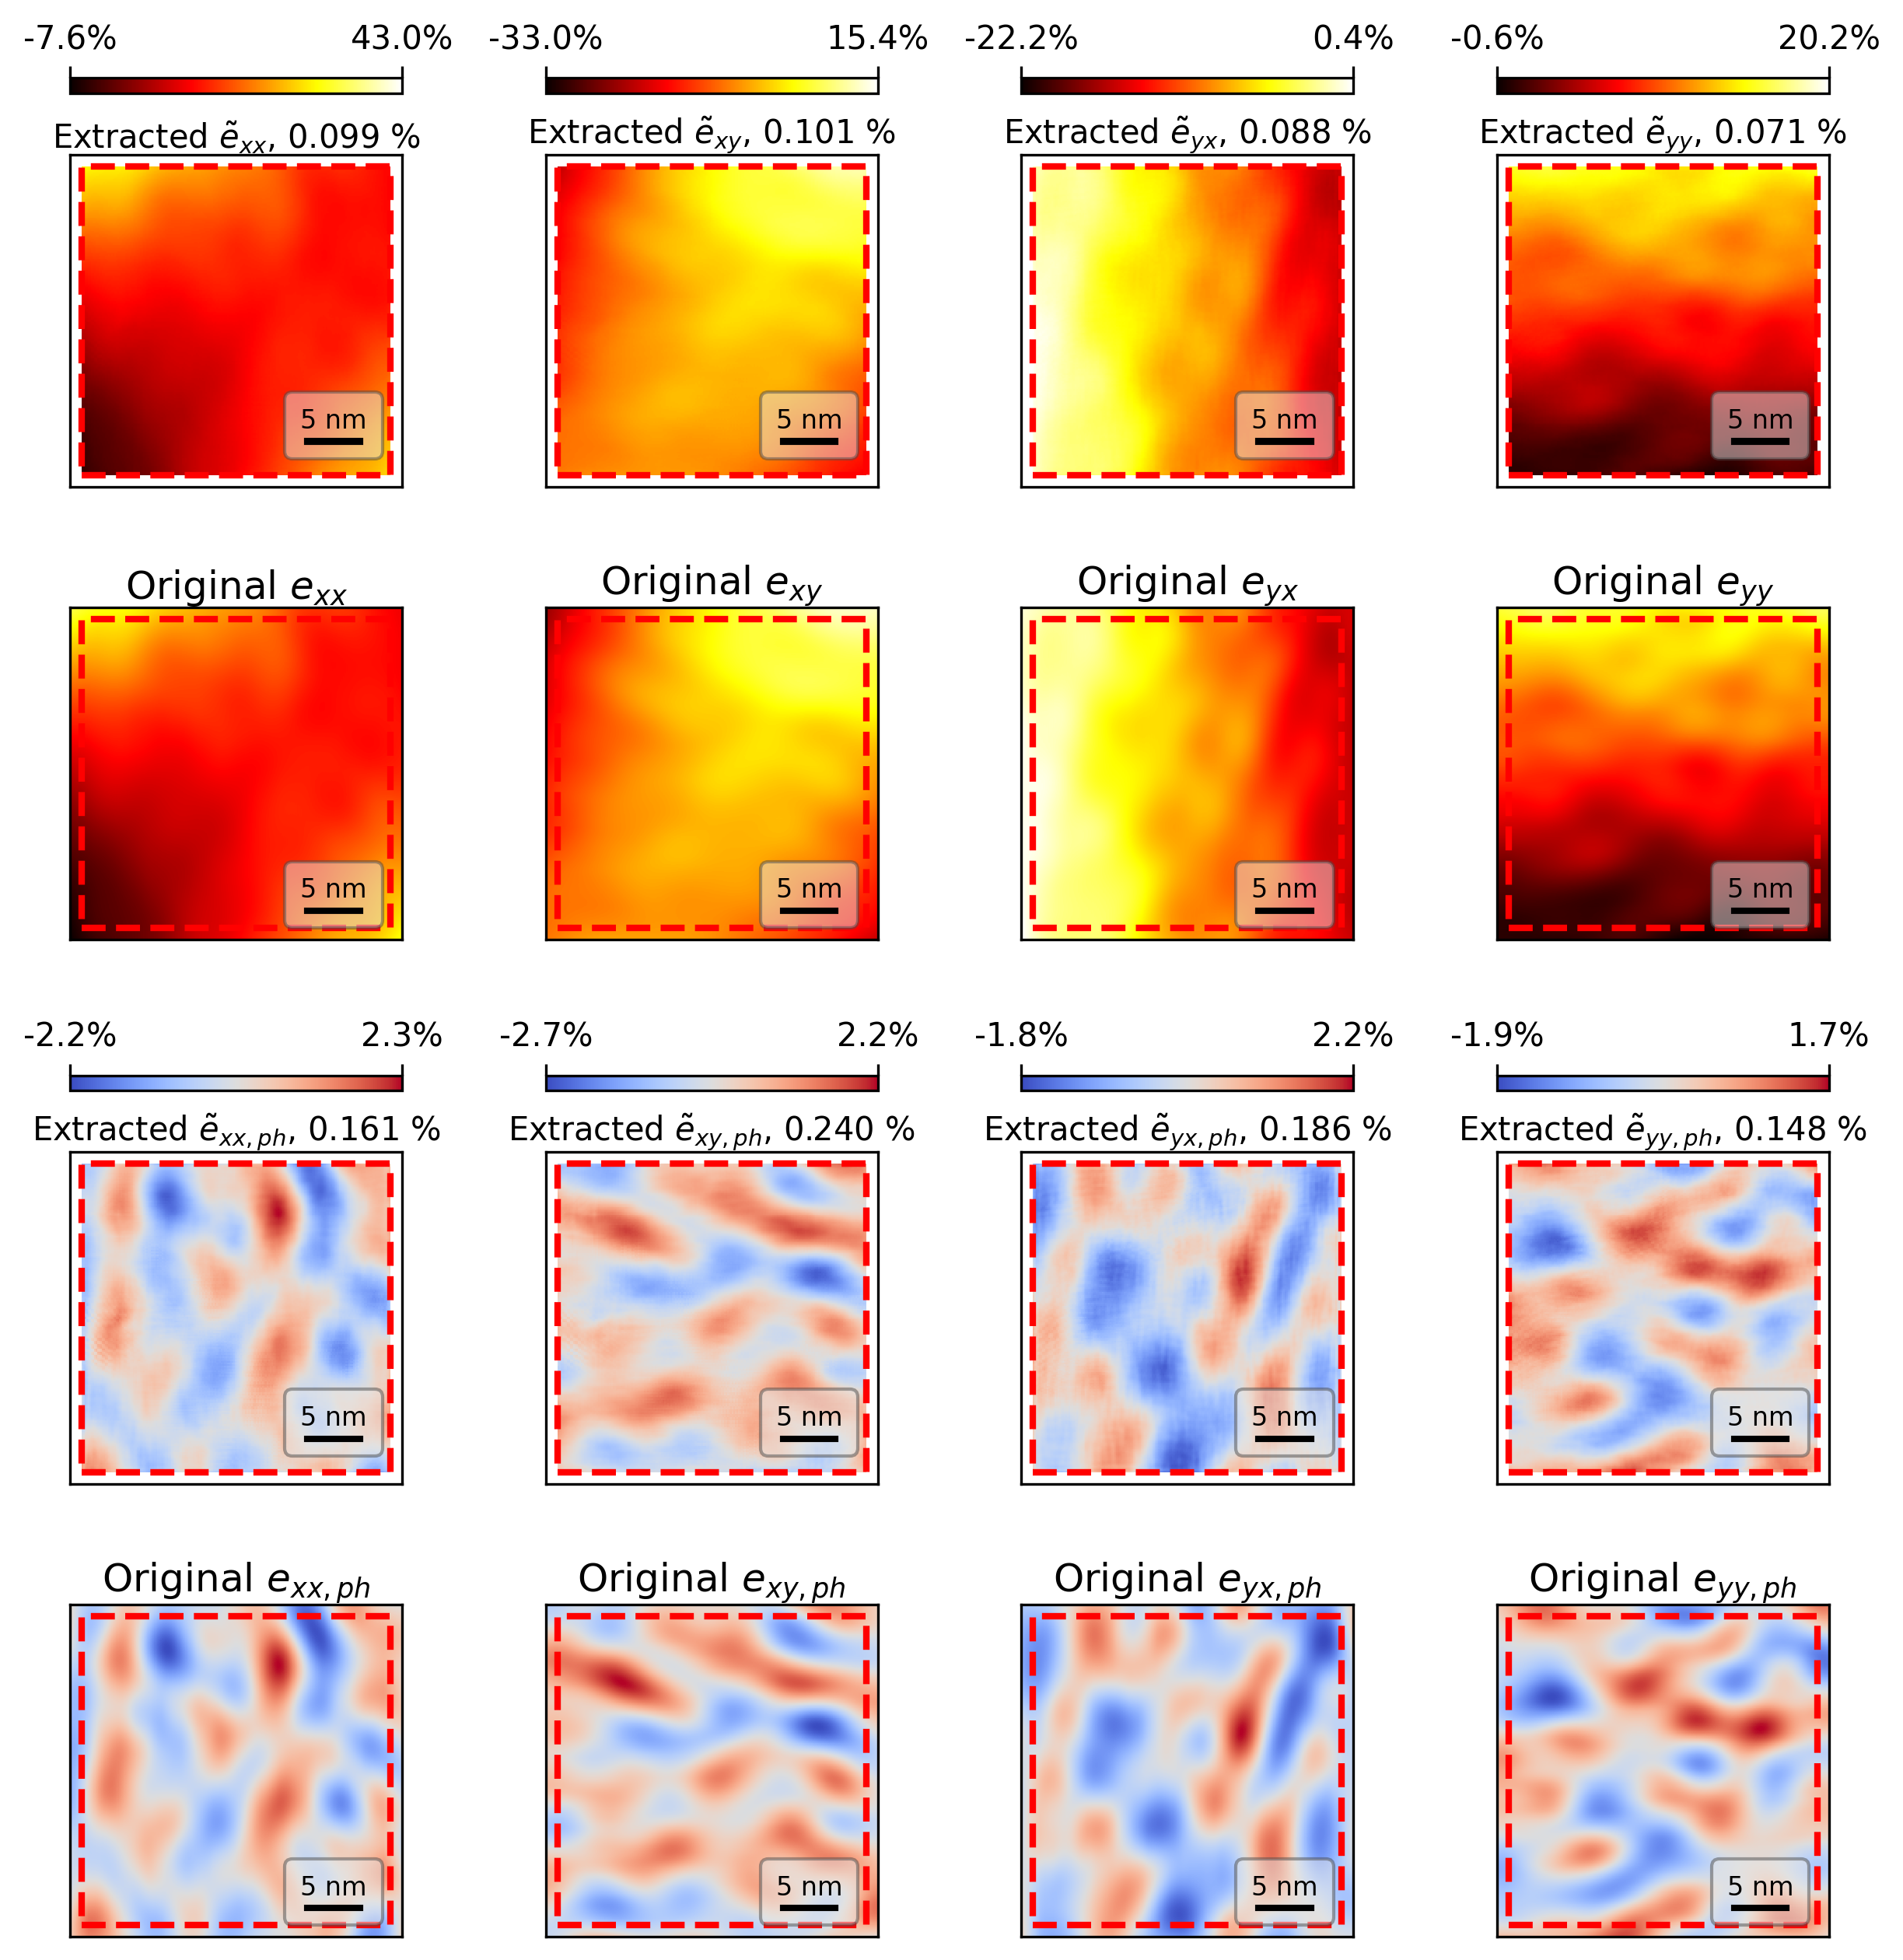

In [16]:
fig = plt.figure(figsize=(8.26, 8.75))
ax_exx = fig.add_subplot(2, 4, 1)
ax_exy = fig.add_subplot(2, 4, 2)
ax_eyx = fig.add_subplot(2, 4, 3)
ax_eyy = fig.add_subplot(2, 4, 4)

ax_exx_ph = fig.add_subplot(2, 4, 5)
ax_exy_ph = fig.add_subplot(2, 4, 6)
ax_eyx_ph = fig.add_subplot(2, 4, 7)
ax_eyy_ph = fig.add_subplot(2, 4, 8)

def add_plot(ax, e_matrix, E_matrix, vmin, vmax, cmap):
    divider = make_axes_locatable(ax)
    ax_e = divider.append_axes("bottom", size="3000%", pad=0.01)
    ax_E = divider.append_axes("bottom", size="3000%", pad=0.01)
    
    # Plot e_matrix
    
    # cmap plot
    map_e = ax_e.pcolorfast(calc.x_region, calc.y_region, e_matrix, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    # Add scale bar
    scale_bar_e = AnchoredSizeBar(ax_e.transData,  5, '5 nm', 
                                'lower right', pad=0.3, label_top=True,
                                color='black', frameon=True, size_vertical=0.3,
                                fontproperties={'size': 8},
                                bbox_to_anchor=(0.925, 0.1),     # shift from edges
                                bbox_transform=ax_e.transAxes,
                                )
    scale_bar_e.patch.set_facecolor('0.9')   # light gray
    scale_bar_e.patch.set_edgecolor('0.3')
    scale_bar_e.patch.set_alpha(0.5)
    scale_bar_e.patch.set_boxstyle("round")
    # Add Frame Box
    valid_boundary_e = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), 
                                        L_region, L_region, 
                                        linewidth=2, linestyle='--', 
                                        edgecolor='red', facecolor='none')
    ax_e.add_patch(valid_boundary_e)
    
    ax_e.add_artist(scale_bar_e)
    ax_e.set_xlim(0, L0)
    ax_e.set_ylim(0, L0)
    ax_e.set_aspect('equal')
    ax_e.set_xticks([])
    ax_e.set_yticks([])
    
    
    # Plot e_matrix
    
    # cmap plot
    map_E = ax_E.pcolorfast(x, y, E_matrix, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    # Add scale bar
    scale_bar_E = AnchoredSizeBar(ax_E.transData,  5, '5 nm', 
                                'lower right', pad=0.3, label_top=True,
                                color='black', frameon=True, size_vertical=0.3,
                                fontproperties={'size': 8},
                                bbox_to_anchor=(0.925, 0.05),     # shift from edges
                                bbox_transform=ax_E.transAxes,
                                )
    scale_bar_E.patch.set_facecolor('0.9')   # light gray
    scale_bar_E.patch.set_edgecolor('0.3')
    scale_bar_E.patch.set_alpha(0.5)
    scale_bar_E.patch.set_boxstyle("round")
    # Add Frame Box
    valid_boundary_E = mpatches.Rectangle((calc.x_region[0], calc.y_region[0]), 
                                        L_region, L_region, 
                                        linewidth=2, linestyle='--', 
                                        edgecolor='red', facecolor='none')
    ax_E.add_patch(valid_boundary_E)
    
    ax_E.add_artist(scale_bar_E)
    ax_E.set_xlim(0, L0)
    ax_E.set_ylim(0, L0)
    ax_E.set_aspect('equal')
    ax_E.set_xticks([])
    ax_E.set_yticks([])
    
    cbar = fig.colorbar(map_e, cax=ax, orientation='horizontal', pad=0.1)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([vmin, vmax])
    ax.set_xticklabels([f'{vmin*100:.1f}%', f'{vmax*100:.1f}%'])
    ax.set_yticks([])
    
    return ax_e, ax_E

cmap = 'hot'
vmin_xx = min(np.min(Exx), np.min(exx))
vmax_xx = max(np.max(Exx), np.max(exx))

vmin_xy = min(np.min(Exy), np.min(exy))
vmax_xy = max(np.max(Exy), np.max(exy))

vmin_yx = min(np.min(Eyx), np.min(eyx))
vmax_yx = max(np.max(Eyx), np.max(eyx))

vmin_yy = min(np.min(Eyy), np.min(eyy))
vmax_yy = max(np.max(Eyy), np.max(eyy))

ax_e, ax_E = add_plot(ax_exx, exx_r, Exx, vmin_xx, vmax_xx, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{xx}$, %.3f %%' % (error_xx * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{xx}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_exy, exy_r, Exy, vmin_xy, vmax_xy, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{xy}$, %.3f %%' % (error_xy * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{xy}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_eyx, eyx_r, Eyx, vmin_yx, vmax_yx, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{yx}$, %.3f %%' % (error_yx * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{yx}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_eyy, eyy_r, Eyy, vmin_yy, vmax_yy, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{yy}$, %.3f %%' % (error_yy * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{yy}$', pad=0.1, fontsize=12)



cmap = 'coolwarm'
vmin_xx_ph = min(np.min(Exx_ph), np.min(exx_ph))
vmax_xx_ph = max(np.max(Exx_ph), np.max(exx_ph))

vmin_xy_ph = min(np.min(Exy_ph), np.min(exy_ph))
vmax_xy_ph = max(np.max(Exy_ph), np.max(exy_ph))

vmin_yx_ph = min(np.min(Eyx_ph), np.min(eyx_ph))
vmax_yx_ph = max(np.max(Eyx_ph), np.max(eyx_ph))

vmin_yy_ph = min(np.min(Eyy_ph), np.min(eyy_ph))
vmax_yy_ph = max(np.max(Eyy_ph), np.max(eyy_ph))

ax_e, ax_E = add_plot(ax_exx_ph, exx_ph, Exx_ph, vmin_xx_ph, vmax_xx_ph, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{xx, ph}$, %.3f %%' % (error_xx_ph * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{xx, ph}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_exy_ph, exy_ph, Exy_ph, vmin_xy_ph, vmax_xy_ph, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{xy, ph}$, %.3f %%' % (error_xy_ph * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{xy, ph}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_eyx_ph, eyx_ph, Eyx_ph, vmin_yx_ph, vmax_yx_ph, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{yx, ph}$, %.3f %%' % (error_yx_ph * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{yx, ph}$', pad=0.1, fontsize=12)
ax_e, ax_E = add_plot(ax_eyy_ph, eyy_ph, Eyy_ph, vmin_yy_ph, vmax_yy_ph, cmap=cmap)
ax_e.set_title('Extracted $\\tilde{e}_{yy, ph}$, %.3f %%' % (error_yy_ph * 100), pad=0.1, fontsize=10)
ax_E.set_title('Original $e_{yy, ph}$', pad=0.1, fontsize=12)


fig.tight_layout()
plt.show()